# biapy

In [3]:
train_data_path = 'training_data/images'
train_data_gt_path = 'training_data/labels'
test_data_path = 'test_data/images'
test_data_gt_path = 'test_data/labels'
patch_size = 256
input_channels = 1
number_of_epochs = 500
percentage_validation = 20

# Identifier of this training run. Results are written to
# <output_path>/<job_name>/results/<job_name>_<run_id>/ , so keep this in sync
# with the run_id passed to BiaPy() and used by the plotting cell below.
run_id = 2

checkpoint_path = '/home/mpaul2/NL-BioImageAnalysis-course2026/day_3/AI_training/biapy_output/my_model_500/checkpoints/my_model_500_2-checkpoint-best.pth'

In [4]:
import yaml
with open( '2d_instance_segmentation.yaml', 'r') as stream:
    try:
        biapy_config = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

In [5]:
# update paths to data
biapy_config['DATA'] = {}
biapy_config['DATA']['TRAIN'] = {}
biapy_config['DATA']['TRAIN']['PATH'] = train_data_path
biapy_config['DATA']['TRAIN']['GT_PATH'] = train_data_gt_path

biapy_config['DATA']['TEST'] = {}
biapy_config['DATA']['TEST']['PATH'] = test_data_path
biapy_config['DATA']['TEST']['GT_PATH'] = test_data_gt_path
biapy_config['DATA']['TEST']['LOAD_GT'] = True

# update data patch size
biapy_config['DATA']['PATCH_SIZE'] = '(' + str(patch_size) + ', ' + str(patch_size) + ', ' + str(input_channels) + ')'

# Reserve part of the training data for validation; test_data remains held out.
biapy_config['DATA']['VAL'] = {}
biapy_config['DATA']['VAL']['FROM_TRAIN'] = True
biapy_config['DATA']['VAL']['SPLIT_TRAIN'] = percentage_validation / 100.0

# update training parameters
biapy_config['TRAIN'] = {}
biapy_config['TRAIN']['EPOCHS'] = number_of_epochs
if number_of_epochs < 10:
    biapy_config['LOG'] = {}
    biapy_config['LOG']['CHART_CREATION_FREQ'] = 1
biapy_config['TRAIN']['ENABLE'] = True

biapy_config['MODEL']['SOURCE'] = 'biapy'
biapy_config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = 'BC'
biapy_config['PROBLEM']['INSTANCE_SEG']['DATA_MW_TH_TYPE'] = 'auto'

# Available models: 'U-Net', 'Residual U-Net', 'Attention U-Net',
# 'MultiResUNet', 'SEUNet', 'ResUNet++', 'UNETR-Mini', 'UNETR-Small', 'UNETR-Base'
biapy_config['MODEL']['ARCHITECTURE'] = 'unet'

if checkpoint_path != '':
    biapy_config['PATHS'] = {}
    biapy_config['PATHS']['CHECKPOINT_FILE'] = checkpoint_path
    biapy_config['MODEL'] = {}
    biapy_config['MODEL']['LOAD_CHECKPOINT'] = True

# Class rebalance
biapy_config['LOSS'] = {}
biapy_config['LOSS']['CLASS_REBALANCE'] = True

# Run inference and evaluation on the held-out test set.
biapy_config['TEST']['ENABLE'] = True

yaml_file = '2d_instance_segmentation_config.yaml'
with open(yaml_file, 'w') as outfile:
    yaml.dump(biapy_config, outfile, default_flow_style=False)

In [6]:
output_path = 'biapy_output'
job_name = "my_model_500_500"

In [7]:
from biapy import BiaPy
biapy = BiaPy(config='2d_instance_segmentation_config.yaml', result_dir=output_path, name=job_name, run_id=run_id, gpu="0")
biapy.run_job()

Date     : 2026-09-09 21:08:32
Arguments: Namespace(config='2d_instance_segmentation_config.yaml', result_dir='biapy_output', name='my_model_500_500', run_id=2, gpu='0', world_size=1, local_rank=-1, dist_on_itp=False, dist_url='env://', dist_backend='nccl')
Job      : my_model_500_500_2
BiaPy    : 3.6.8
Python   : 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:50:00) [GCC 14.3.0]
PyTorch  : 2.5.1
The following changes were made in order to adapt the input configuration:
Not using distributed mode
[21:08:32.502121] Configuration details:
[21:08:32.502162] AUGMENTOR:
  AFFINE_MODE: reflect
  AUG_NUM_SAMPLES: 10
  AUG_SAMPLES: True
  BRIGHTNESS: False
  BRIGHTNESS_FACTOR: (-0.1, 0.1)
  CBLUR_DOWN_RANGE: (2, 8)
  CBLUR_INSIDE: True
  CBLUR_SIZE: (0.2, 0.4)
  CHANNEL_SHUFFLE: False
  CMIX_SIZE: (0.2, 0.4)
  CNOISE_NB_ITERATIONS: (1, 3)
  CNOISE_SCALE: (0.05, 0.1)
  CNOISE_SIZE: (0.2, 0.4)
  CONTRAST: False
  CONTRAST_FACTOR: (-0.1, 0.1)
  COUT_APPLY_TO_MASK: False
  COUT_CVAL: 0

100%|██████████| 128/128 [00:00<00:00, 11570.74it/s]


[21:08:32.950006] *** Loaded data shape is (128, 256, 256)
[21:08:32.950047] * Loading train GT . . .


100%|██████████| 128/128 [00:00<00:00, 7792.14it/s]


[21:08:32.968079] *** Loaded data shape is (128, 256, 256)
[21:08:32.968116] * Loading validation images . . .


...

[21:18:57.582919] Creating instances with watershed . . .


[21:18:57.588590] Thresholds used: {'seed': [0.4590560495853424, 0.40987443923950195], 'growth_mask': [0.2295280247926712]}
[21:18:57.592976] Saving (1, 1, 260, 348, 1) data as .tif in folder: biapy_output/my_model_500_500/results/my_model_500_500_2/per_image_instances


[21:18:57.596993] Calculating matching stats . . .
[21:18:57.597055] Its respective image seems to be: test_data/labels/1899010.tif


[21:18:57.633383] DatasetMatching: {'criterion': 'iou', 'thresh': 0.3, 'fp': np.int64(21), 'tp': np.int64(75), 'fn': np.int64(4), 'precision': np.float64(0.78125), 'recall': np.float64(0.9493670886075949), 'accuracy': np.float64(0.75), 'f1': np.float64(0.8571428571428571), 'n_true': 79, 'n_pred': 96, 'mean_true_score': np.float32(0.6630117), 'mean_matched_score': np.float64(0.6983723449707031), 'panoptic_quality': np.float64(0.5986048671177455)}
[21:18:57.635059] DatasetMatching: {'criterion': 'iou', 'thresh': 0.5, 'fp': np.int64(30), 'tp': np.int64(66), 'fn': np.int64(13), 'precision': np.float64(0.6875), 'recall': np.float64(0.8354430379746836), 'accuracy': np.float64(0.6055045871559633), 'f1': np.float64(0.7542857142857143), 'n_true': 79, 'n_pred': 96, 'mean_true_score': np.float32(0.6126431), 'mean_matched_score': np.float64(0.7333152655399207), 'panoptic_quality': np.float64(0.5531292288643973)}
[21:18:57.636619] DatasetMatching: {'criterion': 'iou', 'thresh': 0.75, 'fp': np.int64

<Figure size 640x480 with 0 Axes>

Resulting images are in `biapy_output/my_model_500_500/results/my_model_500_500_2/per_image_instances`

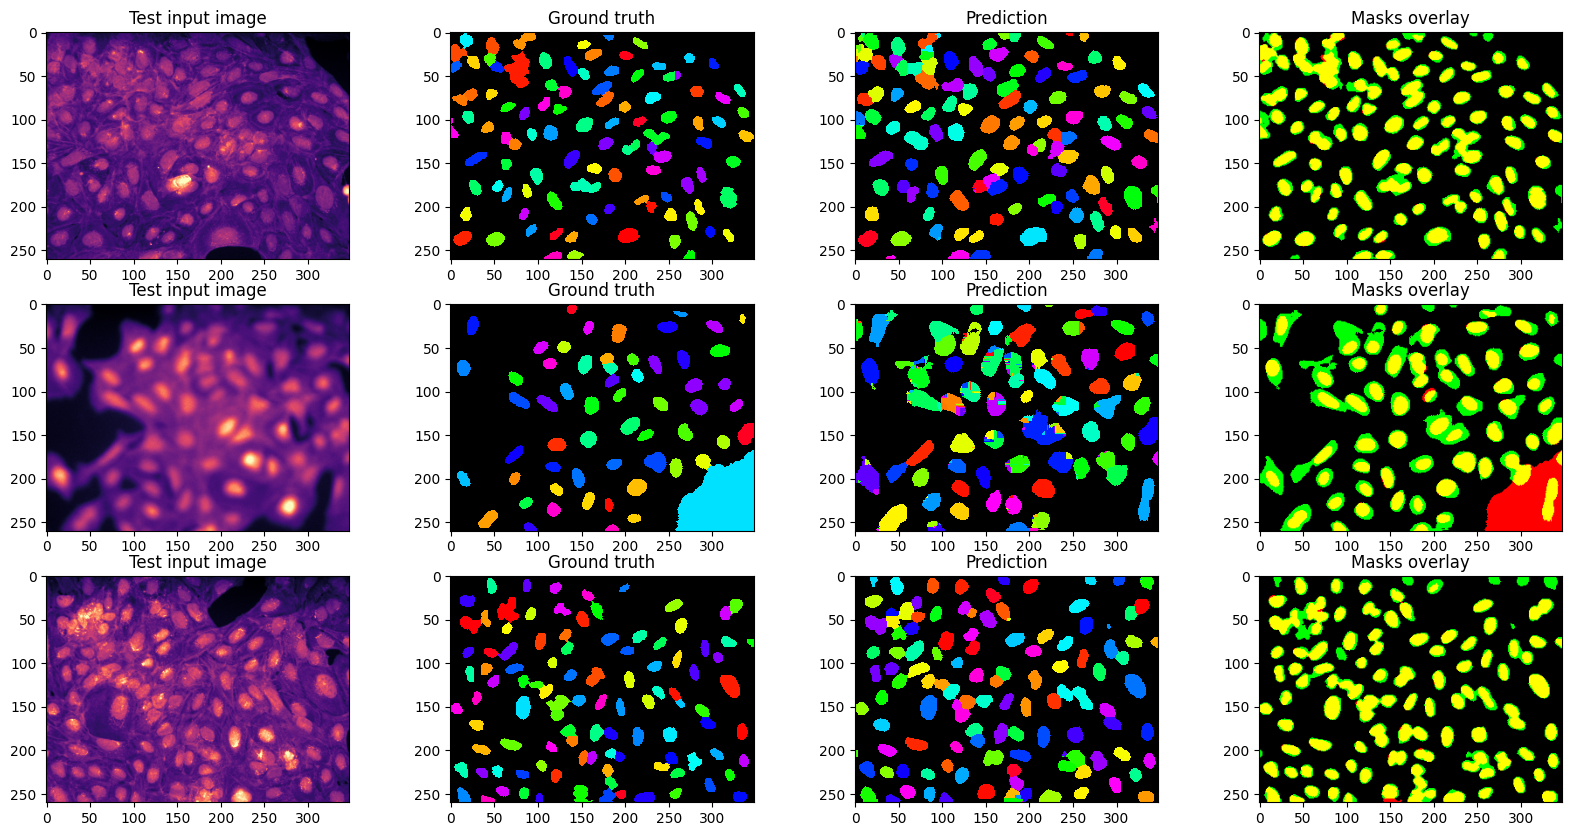

In [8]:
#@markdown ##Play to visualize some results from the test set
#@markdown The trained model was applied to the test images during the run; this cell shows, for a few of them:
#@markdown 1. The original **Test input image**.
#@markdown 2. Its corresponding **Ground truth** labels.
#@markdown 3. The model **Prediction** labels.
#@markdown 4. The **Masks overlay** (true positive pixels in yellow, false negative pixels in red, false positive pixels in green).

%matplotlib inline
import os
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread
from IPython.display import display, Markdown as md

# Same run_id as the training cell; default to 2 if this cell is run on its own.
try:
    run_id
except NameError:
    run_id = 2

# Whether the run predicted full images or per-patch; fall back to the config file on disk.
try:
    full_img = bool(biapy_config['TEST']['FULL_IMG'])
except NameError:
    import yaml
    with open('2d_instance_segmentation_config.yaml') as f:
        full_img = bool(yaml.safe_load(f).get('TEST', {}).get('FULL_IMG', False))

final_results = os.path.join(output_path, job_name, 'results', job_name + '_' + str(run_id))
instance_results = os.path.join(
    final_results, 'full_image_instances' if full_img else 'per_image_instances'
)

if not os.path.isdir(instance_results):
    raise FileNotFoundError(
        "Test predictions not found: {}\n"
        "Re-run the config cell and the training cell with TEST.ENABLE = True "
        "(and a matching run_id) so BiaPy writes the test-set instance masks.".format(instance_results)
    )

display(md("Resulting images are in `{}`".format(instance_results)))

ids_pred = sorted(f for f in os.listdir(instance_results) if f.lower().endswith(('.tif', '.tiff', '.png')))
ids_input = sorted(f for f in os.listdir(test_data_path) if f.lower().endswith(('.tif', '.tiff', '.png')))
ids_gt = sorted(f for f in os.listdir(test_data_gt_path) if f.lower().endswith(('.tif', '.tiff', '.png')))

# random color map for the instance labels (background forced to black)
seed = 1
rng = np.random.default_rng(seed)
vals = np.linspace(0, 1, 256)
rng.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gist_rainbow(vals))
cmap.colors[0] = [0., 0., 0., 1.]

n_available = min(len(ids_input), len(ids_pred), len(ids_gt))
samples_to_show = min(n_available, 3)
chosen_images = rng.choice(n_available, samples_to_show, replace=False)

test_samples, test_sample_preds, test_sample_gt = [], [], []
for k in chosen_images:
    test_samples.append(imread(os.path.join(test_data_path, ids_input[k])))
    test_sample_preds.append(imread(os.path.join(instance_results, ids_pred[k])).astype(np.uint16))
    test_sample_gt.append(imread(os.path.join(test_data_gt_path, ids_gt[k])).astype(np.uint16))

plt.figure(figsize=(20, 10))
index = 1
for j in range(samples_to_show):
    plt.subplot(samples_to_show, 4, index)
    plt.title("Test input image")
    plt.imshow(test_samples[j], cmap='magma',
               vmin=np.percentile(test_samples[j], 0.1), vmax=np.percentile(test_samples[j], 99.9))

    index += 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Ground truth")
    plt.imshow(test_sample_gt[j], cmap=cmap, interpolation='nearest')

    index += 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Prediction")
    plt.imshow(test_sample_preds[j], cmap=cmap, interpolation='nearest')

    index += 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Masks overlay")
    b = np.zeros(test_sample_gt[j].shape)
    overlay = np.dstack((test_sample_gt[j] > 0, test_sample_preds[j] > 0, b))
    plt.imshow(overlay)

    index += 1
plt.show()

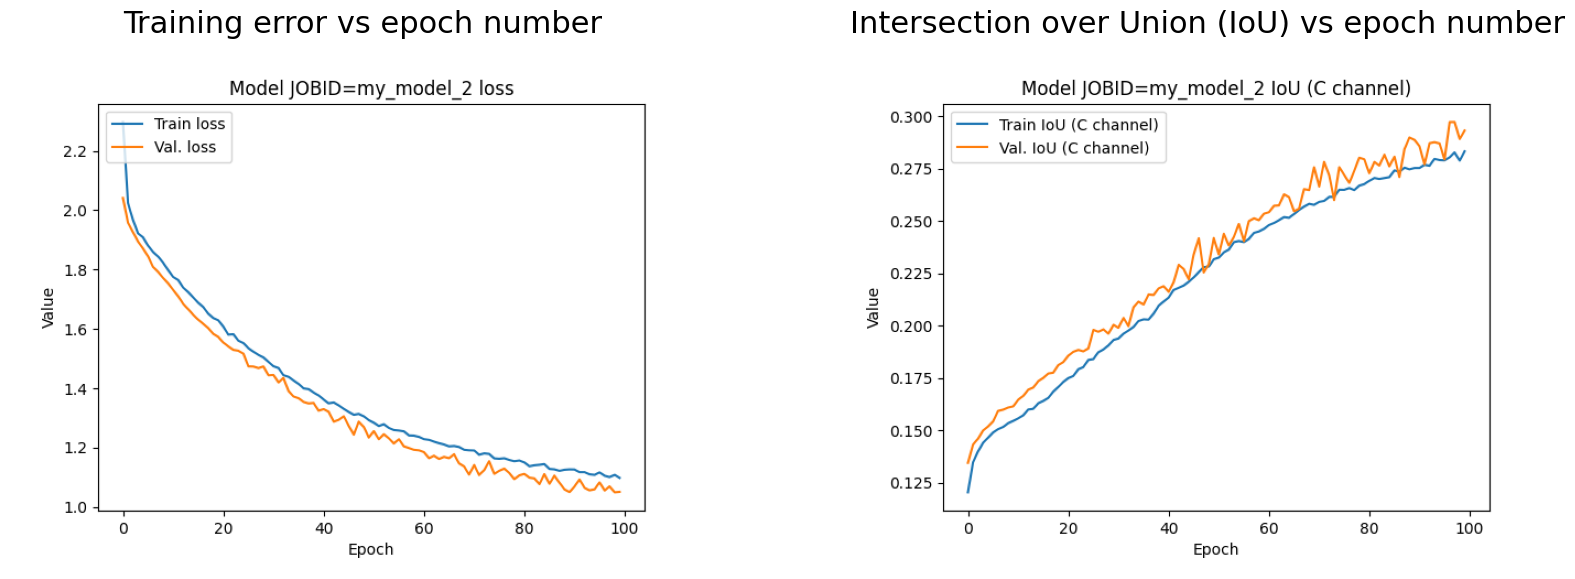

In [10]:
#@markdown ##Play the cell to show a plot of training error vs. epoch number and IoU vs epoch number
#@markdown #### Each channel that composes the instance representation has its own chart. Here, only the first plot found in the 'chart' result folder is shown, but there may be more depending on the selected representation.
import os
import matplotlib.pyplot as plt
from skimage.io import imread

output_path = 'biapy_output'
job_name = "my_model"
# Use the same run_id as the training cell; default to 2 if this cell is run on its own.
try:
    run_id
except NameError:
    run_id = 2

plot_dir = os.path.join(output_path, job_name, 'results', job_name + '_' + str(run_id), 'charts')
if not os.path.isdir(plot_dir):
    raise FileNotFoundError(
        "Charts folder not found: {}\n"
        "Run the training cell above first (and make sure its run_id matches).".format(plot_dir)
    )

plots = sorted(f for f in os.listdir(plot_dir) if f.lower().endswith('.png'))

loss_file = [x for x in plots if "loss" in x][0]
loss_plot = imread(os.path.join(plot_dir, loss_file))

first_channel_file = [x for x in plots if "loss" not in x][0]
iou_plot = imread(os.path.join(plot_dir, first_channel_file))

fig = plt.figure( figsize = (20,10))
ax1 = plt.subplot( 1, 2, 1 )
_ = plt.imshow( loss_plot )
_ = plt.axis('off')
ax1.set_title( 'Training error vs epoch number', fontdict = {'fontsize':22})

ax2 = plt.subplot( 1, 2, 2 )
_ = plt.imshow( iou_plot )
_ = plt.axis('off')
_= ax2.set_title( 'Intersection over Union (IoU) vs epoch number', fontdict = {'fontsize':22})